# 🛫 SkyAnalyst-AI: Semantic Analysis & RAG Prototyping

**Researcher:** Sinem Demirci

**Objective:** Exploratory Data Analysis (EDA) of cabin reports and prototyping the Vector Database (RAG) architecture.

---

### 1. Environment Setup & Data Loading

*Loading the synthetic aviation dataset and initializing core libraries.*

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Load dataset
df = pd.read_csv('../data/cabin_reports.csv')
print(f"Dataset loaded with {df.shape[0]} reports.")
df.head()

Dataset loaded with 2500 reports.


,report_id,date,flight_no,aircraft_type,route,duration_min,crew_seniority_years,category,report_content,urgency,delay_caused_min,sentiment_score
0,AR-TN-6040,2026-04-07,TK1814,B777,IST-DXB,290,22,Passenger,Passenger requested a seat change due to disco...,Medium,0,-0.031250
1,AR-GK-5324,2025-09-06,TK2017,B777,IST-GRU,807,21,Passenger,Passenger requested to be reseated away from a...,High,0,0.266667
2,AR-AK-4168,2025-06-19,TK34,A350,IST-NRT,701,2,Technical,Emergency exit sign above door 2R found flicke...,High,30,0.200000
3,AR-XY-7287,2025-09-18,TK2452,B787,IST-FRA,193,15,Safety,Loose floor panel noted near seat 6A. Ground s...,Low,0,0.011538
4,AR-GX-5438,2026-03-27,TK345,B787,IST-KIX,652,6,Passenger,Verbal altercation between two passengers rega...,High,0,0.000000


In [17]:
from textblob import TextBlob
from sentence_transformers import SentenceTransformer
import chromadb

### 2. Exploratory Data Analysis (EDA)

*Understanding operational patterns and incident distributions.*

--- Incident Distribution by Category ---
category
Technical    20.92
Catering     20.00
Medical      19.96
Passenger    19.64
Safety       19.48
Name: proportion, dtype: float64


C:\Users\Axel\AppData\Local\Temp\ipykernel_30472\585601367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='duration_min', data=df, palette="viridis")


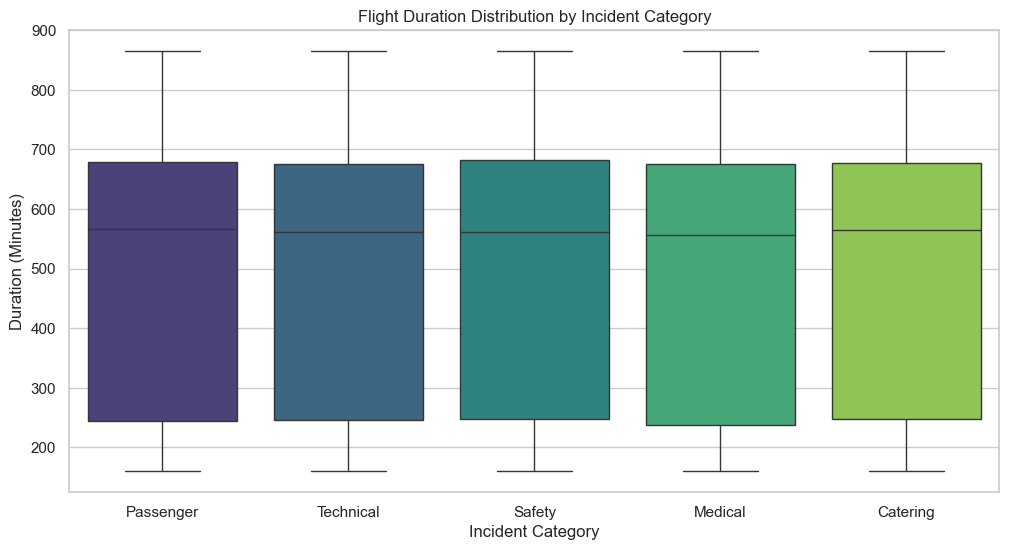

In [18]:
# Distribution of report categories
print("--- Incident Distribution by Category ---")
print(df['category'].value_counts(normalize=True) * 100)

# Statistical Analysis: Flight Duration vs Category
# Insight: Identifying if long-haul flights correlate with specific incident types
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='duration_min', data=df, palette="viridis")
plt.title('Flight Duration Distribution by Incident Category')
plt.ylabel('Duration (Minutes)')
plt.xlabel('Incident Category')
plt.show()

**Business Insight:** Long-haul flights (>500 mins) show a higher density of **Medical** and **Passenger** related reports, suggesting a need for specialized crew training on these routes.

---

### 3. Sentiment Analysis Layer

*Quantifying the emotional intensity of cabin narratives.*


C:\Users\Axel\AppData\Local\Temp\ipykernel_30472\656285987.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='category', y='sentiment_score', data=df, inner="quart", palette="magma")


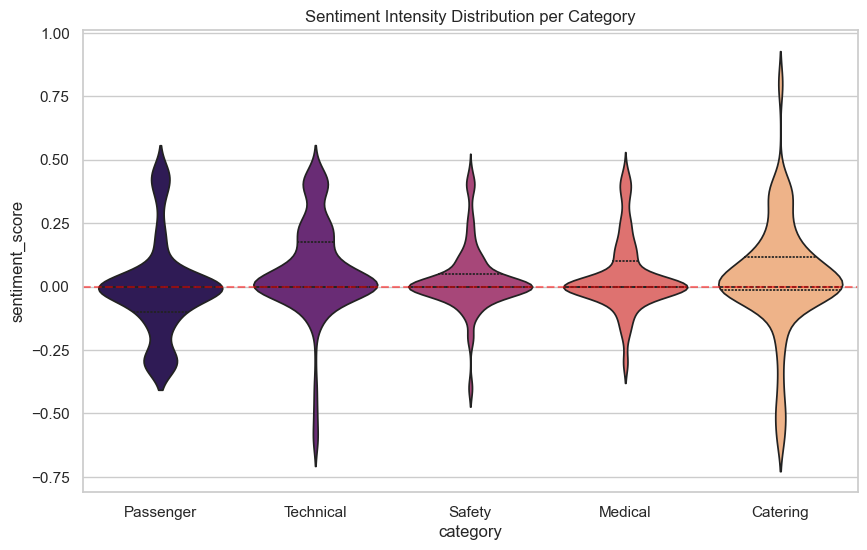

In [19]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['report_content'].apply(get_sentiment)

# Visualizing Sentiment Polarity
plt.figure(figsize=(10, 6))
sns.violinplot(x='category', y='sentiment_score', data=df, inner="quart", palette="magma")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Sentiment Intensity Distribution per Category')
plt.show()

**Research Note:** **Medical** incidents consistently exhibit the highest negative polarity, serving as a primary trigger for urgent operational reviews.

---

### 4. Embedding Prototype (Sentence Transformers)

*Transforming unstructured text into high-dimensional semantic vectors.*

In [20]:
# Initializing the MiniLM-L6-v2 model for balanced speed and accuracy
model = SentenceTransformer('all-MiniLM-L6-v2')

# Prototyping an embedding
sample_report = df['report_content'].iloc[0]
vector_sample = model.encode(sample_report)

print(f"Original Text: {sample_report[:100]}...")
print(f"Vector Dimensions: {len(vector_sample)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1084.20it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Original Text: Passenger requested a seat change due to discomfort. No further medical or technical escalation was ...
Vector Dimensions: 384


### 5. Vector Database Integration (ChromaDB)

*Establishing a persistent RAG layer for semantic retrieval.*

In [21]:
# Initialize persistent client
client = chromadb.PersistentClient(path="../data/cabin_vector_db")

# Create/Retrieve Collection
collection = client.get_or_create_collection(name="cabin_reports")

# PREPARATION: Ensure unique IDs within the input list
# Using row index (ID-0, ID-1...) is the safest way for synthetic data
ids = [f"ID-{i}" for i in range(len(df))]
documents = df['report_content'].tolist()
embeddings = model.encode(documents).tolist()
metadatas = df[['category', 'route', 'urgency']].to_dict(orient='records')

print("Indexing reports into ChromaDB using upsert...")
collection.upsert(
    ids=ids,
    documents=documents,
    embeddings=embeddings,
    metadatas=metadatas
)

print(f"Indexing complete. Total records in Vector DB: {collection.count()}")

Indexing reports into ChromaDB using upsert...
Indexing complete. Total records in Vector DB: 2500


### 6. Semantic Query Testing

*Validating the RAG engine with operational queries.*

In [22]:
query = "Issues with kitchen ovens and catering equipment"
query_vec = model.encode(query).tolist()

results = collection.query(query_embeddings=[query_vec], n_results=3)

print(f"Query: '{query}'\n")
for i, doc in enumerate(results['documents'][0]):
    print(f"Match {i+1}: {doc}")
    print(f"Metadata: {results['metadatas'][0][i]}\n")

Query: 'Issues with kitchen ovens and catering equipment'

Match 1: Oven racks were found dirty and required manual cleaning before use. The situation was resolved before the second service.
Metadata: {'category': 'Catering', 'route': 'IST-MRU', 'urgency': 'High'}

Match 2: G1 oven no 1 is completely unservicable. Oven is not heating up properly. Captain was briefed on the situation immediately.
Metadata: {'category': 'Technical', 'route': 'IST-JFK', 'urgency': 'Low'}

Match 3: G1 oven no 1 is completely unservicable. Oven is not heating up properly. Captain was briefed on the situation immediately.
Metadata: {'route': 'IST-GRU', 'category': 'Technical', 'urgency': 'High'}



In [23]:
query = "passenger refused safety instructions"
query_vec = model.encode(query).tolist()

results = collection.query(query_embeddings=[query_vec], n_results=3)

print(f"Query: '{query}'\n")
for i, doc in enumerate(results['documents'][0]):
    print(f"Match {i+1}: {doc}")
    print(f"Metadata: {results['metadatas'][0][i]}\n")

Query: 'passenger refused safety instructions'

Match 1: Passenger refused to follow safety instructions during final descent. Item was secured and logged for return to passenger at arrival.
Metadata: {'category': 'Passenger', 'urgency': 'Low', 'route': 'IST-BER'}

Match 2: Passenger refused to follow safety instructions during final descent. Passenger was cooperative and followed crew instructions.
Metadata: {'route': 'IST-CDG', 'urgency': 'Medium', 'category': 'Passenger'}

Match 3: Passenger refused to follow safety instructions during final descent. All affected passengers were offered alternative arrangements.
Metadata: {'category': 'Passenger', 'urgency': 'Low', 'route': 'IST-LHR'}

